# CG4002: Voice PyTorch 1D-CNN Trainer & HLS Export

## Notes
1. Augment train only
2. Normalise from train stats only


In [ ]:
# Single package-install cell
%pip install numpy pandas scikit-learn matplotlib seaborn torchaudio pysoundfile


In [22]:
# Single import/config cell
import copy  # Deep-copy best model checkpoint parameters.
import random  # Seed Python RNG for reproducible data ops.
import re  # Match dated dataset folder names with regex.
from datetime import datetime  # Parse date folder strings to datetime objects.
from pathlib import Path  # OS-safe path joins and filesystem traversal.

import matplotlib.pyplot as plt  # Plot confusion matrices and other figures.
import numpy as np  # Numeric arrays and .npy serialization.
import pandas as pd  # Build and persist file manifests.
import seaborn as sns  # Styled heatmaps for confusion matrices.
import soundfile as sf  # Read PCM waveform samples from disk.
import torch  # Core tensors, device selection, and model execution.
import torch.nn as nn  # Layer modules (Conv1d, Linear, activation wrappers).
import torch.nn.functional as F  # Functional ops for HLS-like forward simulation.
import torch.optim as optim  # Optimizers for training.
import torchaudio  # MFCC transform and audio resampling tools.
from sklearn.metrics import accuracy_score, confusion_matrix  # Accuracy + confusion metrics.
from sklearn.model_selection import train_test_split  # Stratified split utilities.
from torch.utils.data import DataLoader, Dataset, TensorDataset  # Batch loading utilities.

# Reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# Core settings
SAMPLE_RATE = 16000
N_MFCC = 40
TARGET_FRAMES = 50
NUM_CLASSES = 3
BATCH_SIZE = 16
EPOCHS = 30
PRETRAIN_EPOCHS = 20  # Kept for reference when synthetic pretraining is enabled.
FINETUNE_EPOCHS = 20  # Kept for reference when synthetic pretraining is enabled.
LEARNING_RATE = 1e-3
FINETUNE_LEARNING_RATE = 3e-4  # Kept for reference when synthetic pretraining is enabled.
WEIGHT_DECAY = 1e-3
VAL_SIZE = 0.2
TEST_SIZE = 0.2
EARLY_STOPPING_PATIENCE = None  # Disabled: always train for all epochs.
LABEL_SMOOTHING = 0.1
DROPOUT_P = 0.35
TRAIN_AUG_MULTIPLIER = 6  # Logical samples per epoch = train_seed * multiplier.
CLIPS_PER_SPEAKER = 5

# Locate latest audio folder
AUDIO_ROOT = Path('../data/audio')
AUDIO_DIR_OVERRIDE = None  # e.g. Path('../data/audio/pokemon_segmented')

def get_latest_audio_folder(root: Path) -> Path:
    candidates = []
    for d in root.iterdir():
        if d.is_dir() and re.fullmatch(r"\d{8}", d.name):
            try:
                candidates.append((datetime.strptime(d.name, '%d%m%Y'), d))
            except ValueError:
                pass
    if not candidates:
        raise RuntimeError(f'No dated audio folders under: {root.resolve()}')
    candidates.sort(key=lambda x: x[0])
    return candidates[-1][1]

AUDIO_DIR = AUDIO_DIR_OVERRIDE if AUDIO_DIR_OVERRIDE is not None else get_latest_audio_folder(AUDIO_ROOT)
print('Using audio folder:', AUDIO_DIR)

MANIFEST_CSV = AUDIO_DIR / 'voice_manifest.csv'
FEATURES_NPY = AUDIO_DIR / 'voice_features.npy'
LABELS_NPY = AUDIO_DIR / 'voice_labels.npy'
TRAIN_NPY = AUDIO_DIR / 'voice_X_train.npy'
TEST_NORM_NPY = AUDIO_DIR / 'voice_X_test_norm.npy'
YTRAIN_NPY = AUDIO_DIR / 'voice_y_train.npy'
YTEST_NPY = AUDIO_DIR / 'voice_y_test.npy'
BOARD_TEST_NPY = AUDIO_DIR / 'voice_X_test.npy'
MEAN_NPY = AUDIO_DIR / 'voice_mean.npy'
STD_NPY = AUDIO_DIR / 'voice_std.npy'
WEIGHTS_H_PATH = AUDIO_DIR / 'voice_cnn_weights.h'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using audio folder: ../data/audio/13032026
Using device: cpu


## 1) Data scan -> MFCC base features


In [23]:
# Build a deterministic manifest with speaker IDs for speaker-disjoint splitting.
def natural_sort_key(path_like):
    parts = re.split(r'(\d+)', str(path_like).lower())
    return [int(part) if part.isdigit() else part for part in parts]


def normalize_speaker_name(name: str) -> str:
    name = re.sub(r'\([^)]*\)', '', name).strip()
    name = re.sub(r'[^a-zA-Z0-9]+', '_', name).strip('_').lower()
    return name or 'speaker'


def infer_speaker_id(audio_path: Path, class_dir: Path, ordinal: int) -> str:
    rel_parts = audio_path.relative_to(class_dir).parts
    if len(rel_parts) > 1:
        return normalize_speaker_name(rel_parts[0])
    speaker_idx = ordinal // CLIPS_PER_SPEAKER
    return f'speaker_{speaker_idx + 1:03d}'


def scan_audio_dataset(root: Path):
    class_dirs = sorted([p for p in root.iterdir() if p.is_dir()], key=lambda p: p.name.lower())
    if not class_dirs:
        raise RuntimeError(f'No class folders in: {root.resolve()}')

    class_map = {d.name: i for i, d in enumerate(class_dirs)}
    allowed_exts = {'.wav', '.m4a'}
    rows = []
    for class_dir in class_dirs:
        lbl_id = class_map[class_dir.name]
        audio_files = sorted([
            p for p in class_dir.rglob('*')
            if p.is_file() and p.suffix.lower() in allowed_exts
        ], key=natural_sort_key)
        for ordinal, audio_path in enumerate(audio_files):
            rows.append({
                'path': str(audio_path),
                'label': class_dir.name,
                'label_id': lbl_id,
                'speaker_id': infer_speaker_id(audio_path, class_dir, ordinal),
                'utterance_id': (ordinal % CLIPS_PER_SPEAKER) + 1,
            })

    if not rows:
        raise RuntimeError('No .wav/.m4a files found.')

    manifest = pd.DataFrame(rows)
    manifest = manifest.sort_values(['label_id', 'speaker_id', 'utterance_id', 'path']).reset_index(drop=True)
    return manifest, class_map


manifest_df, CLASS_MAP = scan_audio_dataset(AUDIO_DIR)
manifest_df.to_csv(MANIFEST_CSV, index=False)
ACTIVE_LABELS = [name for name, idx in sorted(CLASS_MAP.items(), key=lambda kv: kv[1])]
print('Samples:', len(manifest_df))
print('Speakers:', manifest_df['speaker_id'].nunique())
print('Class map:', CLASS_MAP)

# MFCC extractor (40xT)
mfcc_transform = torchaudio.transforms.MFCC(
    # Output tensor is [n_mfcc, frames] before frame fixing/truncation.
    sample_rate=SAMPLE_RATE,
    n_mfcc=N_MFCC,
    melkwargs={
        'n_fft': 512,
        'win_length': 400,
        'hop_length': 160,
        'n_mels': 40,
        'center': True,
        'power': 2.0,
    },
)


def fix_mfcc_time(mfcc_2d, target_frames=TARGET_FRAMES):
    # Force fixed temporal length so Conv1d input is always [40, 50].
    t = mfcc_2d.shape[1]
    if t == target_frames:
        return mfcc_2d
    if t > target_frames:
        return mfcc_2d[:, :target_frames]
    return torch.nn.functional.pad(mfcc_2d, (0, target_frames - t), mode='constant', value=0.0)


def load_waveform_mono_resampled(audio_path):
    # Ensure mono + common sample rate for consistent MFCC extraction.
    audio_path = Path(audio_path).resolve()
    if audio_path.suffix.lower() == '.m4a':
        wav, sr = torchaudio.load(str(audio_path))
        wav = wav.to(torch.float32)
    else:
        audio, sr = sf.read(str(audio_path), dtype='float32')
        wav = torch.from_numpy(audio).T if audio.ndim == 2 else torch.from_numpy(audio).unsqueeze(0)
    if wav.shape[0] > 1:
        wav = wav.mean(dim=0, keepdim=True)
    if sr != SAMPLE_RATE:
        wav = torchaudio.functional.resample(wav, sr, SAMPLE_RATE)
    return wav


def waveform_to_feature(wav):
    # Convert waveform -> MFCC [40,50], then per-sample CMVN
    feat = mfcc_transform(wav).squeeze(0)
    feat = fix_mfcc_time(feat, TARGET_FRAMES)
    mu = feat.mean(dim=1, keepdim=True)
    sd = feat.std(dim=1, keepdim=True).clamp_min(1e-6)
    feat = (feat - mu) / sd
    return feat.numpy().astype(np.float32)


def build_feature_set_from_manifest(df):
    # Converts every audio file into one base feature sample before split/augmentation.
    all_X, all_y = [], []
    for _, row in df.iterrows():
        wav = load_waveform_mono_resampled(row['path'])
        all_X.append(waveform_to_feature(wav))
        all_y.append(int(row['label_id']))
    return np.stack(all_X, axis=0), np.asarray(all_y, dtype=np.int64)


X_base, y_base = build_feature_set_from_manifest(manifest_df)
np.save(FEATURES_NPY, X_base)
np.save(LABELS_NPY, y_base)

print('X_base:', X_base.shape, 'y_base:', y_base.shape)
print('Class counts:', {int(i): int((y_base == i).sum()) for i in np.unique(y_base)})


Samples: 135
Class map: {'bulbasaur': 0, 'charizard': 1, 'pikachu': 2}
X_base: (135, 40, 50) y_base: (135,)
Class counts: {0: 45, 1: 45, 2: 45}


## 2) Speaker-Disjoint Train/Test Split


In [24]:
# Speaker-disjoint split kept for reference only.
# def split_speakers(unique_speakers, test_size=TEST_SIZE, val_size=VAL_SIZE, seed=RANDOM_SEED):
#     speakers = np.asarray(sorted(unique_speakers), dtype=object)
#     if len(speakers) < 3:
#         raise RuntimeError('Need at least 3 speakers for speaker-disjoint train/val/test splits.')
#
#     rng = np.random.default_rng(seed)
#     speakers = speakers.copy()
#     rng.shuffle(speakers)
#
#     n_total = len(speakers)
#     n_test = max(1, int(round(n_total * test_size)))
#     n_val = max(1, int(round((n_total - n_test) * val_size)))
#     while n_total - n_test - n_val < 1:
#         if n_val > 1:
#             n_val -= 1
#         elif n_test > 1:
#             n_test -= 1
#         else:
#             raise RuntimeError('Not enough speakers left for the training split.')
#
#     test_speakers = set(speakers[:n_test].tolist())
#     val_speakers = set(speakers[n_test:n_test + n_val].tolist())
#     train_speakers = set(speakers[n_test + n_val:].tolist())
#     return train_speakers, val_speakers, test_speakers
#
#
# def subset_has_all_labels(df_subset):
#     return set(df_subset['label_id'].tolist()) == set(CLASS_MAP.values())
#
#
# for attempt in range(128):
#     train_speakers, val_speakers, test_speakers = split_speakers(
#         manifest_df['speaker_id'].unique(),
#         seed=RANDOM_SEED + attempt,
#     )
#     train_df = manifest_df[manifest_df['speaker_id'].isin(train_speakers)].copy()
#     val_df = manifest_df[manifest_df['speaker_id'].isin(val_speakers)].copy()
#     test_df = manifest_df[manifest_df['speaker_id'].isin(test_speakers)].copy()
#     if subset_has_all_labels(train_df) and subset_has_all_labels(val_df) and subset_has_all_labels(test_df):
#         break
# else:
#     raise RuntimeError('Failed to find a speaker-disjoint split containing all labels in every split.')
#
# train_mask = manifest_df['speaker_id'].isin(train_speakers).to_numpy()
# val_mask = manifest_df['speaker_id'].isin(val_speakers).to_numpy()
# test_mask = manifest_df['speaker_id'].isin(test_speakers).to_numpy()
#
# X_train_seed = X_base[train_mask].astype(np.float32)
# y_train_seed = y_base[train_mask].astype(np.int64)
# X_val_raw = X_base[val_mask].astype(np.float32)
# y_val = y_base[val_mask].astype(np.int64)
# X_test_raw = X_base[test_mask].astype(np.float32)
# y_test = y_base[test_mask].astype(np.int64)

# Ordinary stratified file split kept for reference only.
# all_idx = np.arange(len(manifest_df))
# all_labels = manifest_df['label_id'].to_numpy(dtype=np.int64)
#
# train_val_idx, test_idx = train_test_split(
#     all_idx,
#     test_size=TEST_SIZE,
#     random_state=RANDOM_SEED,
#     stratify=all_labels,
# )
# train_idx, val_idx = train_test_split(
#     train_val_idx,
#     test_size=VAL_SIZE,
#     random_state=RANDOM_SEED,
#     stratify=all_labels[train_val_idx],
# )

# Two-stage synthetic->real split kept for reference only.
# SYNTH_PRETRAIN_COUNT = 500
# REAL_BLOCK_COUNT = 45
# REAL_FINETUNE_COUNT = 15
# REAL_VAL_COUNT = 15
# REAL_TEST_COUNT = 15

# Active split: real-only training/evaluation on files 501-545.
REAL_START_NUM = 501
REAL_BLOCK_COUNT = 45
REAL_TRAIN_COUNT = 27
REAL_VAL_COUNT = 9
REAL_TEST_COUNT = 9

def path_number(path_str):
    match = re.search(r'_(\d+)$', Path(path_str).stem)
    if match is None:
        raise RuntimeError(f'Could not parse numeric suffix from: {path_str}')
    return int(match.group(1))

real_train_parts, val_parts, test_parts = [], [], []
for label_id in sorted(CLASS_MAP.values()):
    class_df = manifest_df[manifest_df['label_id'] == label_id].copy()
    class_df['file_num'] = class_df['path'].map(path_number)
    class_df = class_df.sort_values('file_num').reset_index()

    real_df = class_df[class_df['file_num'] >= REAL_START_NUM].copy()
    required = REAL_BLOCK_COUNT
    if len(real_df) < required:
        raise RuntimeError(
            f'Label {label_id} has only {len(real_df)} real files from {REAL_START_NUM} onward; '
            f'need at least {required}.'
        )

    real_df = real_df.iloc[:REAL_BLOCK_COUNT].copy()
    real_train_parts.append(real_df.iloc[:REAL_TRAIN_COUNT]['index'].to_numpy(dtype=np.int64))
    val_parts.append(real_df.iloc[REAL_TRAIN_COUNT:REAL_TRAIN_COUNT + REAL_VAL_COUNT]['index'].to_numpy(dtype=np.int64))
    test_parts.append(real_df.iloc[REAL_TRAIN_COUNT + REAL_VAL_COUNT:REAL_TRAIN_COUNT + REAL_VAL_COUNT + REAL_TEST_COUNT]['index'].to_numpy(dtype=np.int64))

train_idx = np.concatenate(real_train_parts)
val_idx = np.concatenate(val_parts)
test_idx = np.concatenate(test_parts)

X_train_seed = X_base[train_idx].astype(np.float32)
y_train_seed = y_base[train_idx].astype(np.int64)
X_val_raw = X_base[val_idx].astype(np.float32)
y_val = y_base[val_idx].astype(np.int64)
X_test_raw = X_base[test_idx].astype(np.float32)
y_test = y_base[test_idx].astype(np.int64)


def augment_feature_np(feat, noise_std=0.03, gain_jitter=0.15, max_time_shift=4, time_mask_max=8, freq_mask_max=6):
    # Stronger feature-domain augmentation for tiny speaker datasets.
    x = feat.copy()
    x *= np.float32(np.random.uniform(1.0 - gain_jitter, 1.0 + gain_jitter))
    x += np.random.normal(0.0, noise_std, size=x.shape).astype(np.float32)

    if max_time_shift > 0:
        shift = int(np.random.randint(-max_time_shift, max_time_shift + 1))
        x = np.roll(x, shift=shift, axis=1)

    for _ in range(2):
        w = int(np.random.randint(0, time_mask_max + 1))
        if 0 < w < x.shape[1]:
            t0 = int(np.random.randint(0, x.shape[1] - w + 1))
            x[:, t0:t0 + w] = 0.0

    for _ in range(2):
        w = int(np.random.randint(0, freq_mask_max + 1))
        if 0 < w < x.shape[0]:
            f0 = int(np.random.randint(0, x.shape[0] - w + 1))
            x[f0:f0 + w, :] = 0.0

    return x.astype(np.float32)


# print('Speaker split:', len(train_speakers), len(val_speakers), len(test_speakers))
print('Train/val/test:', X_train_seed.shape, X_val_raw.shape, X_test_raw.shape)
print(
    f'Per-class real-only split: train={REAL_TRAIN_COUNT}, '
    f'val={REAL_VAL_COUNT}, test={REAL_TEST_COUNT} from files {REAL_START_NUM}+ '
)
# print('Train speakers:', sorted(train_speakers))
# print('Val speakers:', sorted(val_speakers))
# print('Test speakers:', sorted(test_speakers))

# Keep raw board input for fused-normalization deployment path
np.save(BOARD_TEST_NPY, X_test_raw)


Seed split: (97, 40, 50) (11, 40, 50) (27, 40, 50)
Train after augmentation: (679, 40, 50)


## 3) Normalise from train only -> DataLoaders


In [25]:
# Fit normalisation stats on the real training split.
train_mean = X_train_seed.mean(axis=(0, 2), keepdims=True)  # [1,40,1]
train_std = X_train_seed.std(axis=(0, 2), keepdims=True) + 1e-6

X_train = ((X_train_seed - train_mean) / train_std).astype(np.float32)
X_val = ((X_val_raw - train_mean) / train_std).astype(np.float32)
X_test = ((X_test_raw - train_mean) / train_std).astype(np.float32)

# Save artifacts
np.save(MEAN_NPY, train_mean.reshape(-1).astype(np.float32))
np.save(STD_NPY, train_std.reshape(-1).astype(np.float32))
np.save(TRAIN_NPY, X_train)
np.save(TEST_NORM_NPY, X_test)
np.save(YTRAIN_NPY, y_train_seed)
np.save(YTEST_NPY, y_test)

print('Shapes:', X_train.shape, X_val.shape, X_test.shape)
print('Logical train samples per epoch:', len(X_train) * TRAIN_AUG_MULTIPLIER)
print('Saved to:', AUDIO_DIR)


class AugmentedFeatureDataset(Dataset):
    def __init__(self, X, y, train=False, epoch_multiplier=1):
        self.X = X.astype(np.float32)
        self.y = y.astype(np.int64)
        self.train = train
        self.epoch_multiplier = max(1, int(epoch_multiplier))

    def __len__(self):
        return len(self.y) * self.epoch_multiplier if self.train else len(self.y)

    def __getitem__(self, idx):
        base_idx = idx % len(self.y)
        feat = self.X[base_idx].copy()
        if self.train:
            feat = augment_feature_np(feat)
        x = torch.tensor(feat, dtype=torch.float32)
        y = torch.tensor(int(self.y[base_idx]), dtype=torch.long)
        return x, y


train_loader = DataLoader(
    AugmentedFeatureDataset(X_train, y_train_seed, train=True, epoch_multiplier=TRAIN_AUG_MULTIPLIER),
    batch_size=BATCH_SIZE,
    shuffle=True,
)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long)),
    batch_size=BATCH_SIZE,
    shuffle=False,
)
test_loader = DataLoader(
    TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long)),
    batch_size=BATCH_SIZE,
    shuffle=False,
)


Shapes: (679, 40, 50) (11, 40, 50) (27, 40, 50)
Saved to: ../data/audio/13032026


## 4) Model, training, evaluation


Model summary (Keras-style):
Layer (type)       Output Shape        Param #
Conv1d             (1, 16, 50)        1,936
ReLU               (1, 16, 50)        0
MaxPool1d          (1, 16, 25)        0
Conv1d             (1, 32, 25)        1,568
ReLU               (1, 32, 25)        0
AdaptiveAvgPool1d  (1, 32, 1)         0
Linear             (1, 3)             99
Total params: 3,603
Trainable params: 3,603
Non-trainable params: 0
Start training for 60 epochs...
Epoch 1/60 | Loss 1.0937 | Train 42.56% | Val 27.27% | LR 0.001000
Epoch 5/60 | Loss 0.6809 | Train 90.72% | Val 54.55% | LR 0.001000
Epoch 10/60 | Loss 0.0626 | Train 100.00% | Val 63.64% | LR 0.001000
Epoch 15/60 | Loss 0.0175 | Train 100.00% | Val 63.64% | LR 0.000500
Epoch 20/60 | Loss 0.0110 | Train 100.00% | Val 63.64% | LR 0.000250
Epoch 25/60 | Loss 0.0087 | Train 100.00% | Val 63.64% | LR 0.000125
Epoch 30/60 | Loss 0.0075 | Train 100.00% | Val 63.64% | LR 0.000125
Epoch 35/60 | Loss 0.0070 | Train 100.00% | Val 63.64% |

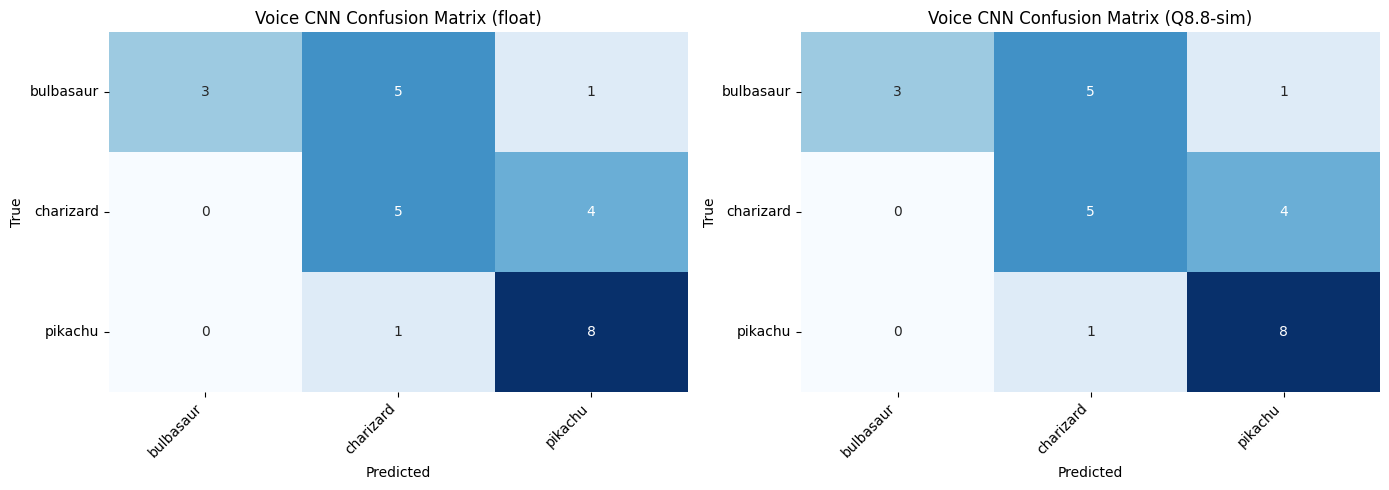

In [29]:
# Model input to forward(): [B, 40, 50] (MFCC channels-first).
class VoiceCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.conv1 = nn.Conv1d(40, 16, kernel_size=3, padding=1)
        # Shape: [B, 40, 50] -> [B, 16, 50].
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(2)
        self.drop1 = nn.Dropout(DROPOUT_P * 0.5)
        # Shape after pool1: [B, 16, 50] -> [B, 16, 25].

        self.conv2 = nn.Conv1d(16, 32, kernel_size=3, padding=1)
        # Shape: [B, 16, 25] -> [B, 32, 25].
        self.relu2 = nn.ReLU()
        self.pool2 = nn.AdaptiveAvgPool1d(1)
        self.drop2 = nn.Dropout(DROPOUT_P)
        # Global average pool over time: [B, 32, 25] -> [B, 32, 1].

        self.fc = nn.Linear(32, num_classes)

    def forward(self, x):
        # Short stack: conv -> pool -> conv -> global pool -> classifier.
        x = self.drop1(self.pool1(self.relu1(self.conv1(x))))
        x = self.drop2(self.pool2(self.relu2(self.conv2(x))))
        x = x.squeeze(-1)
        return self.fc(x)


def print_model_summary(model, sample_input):
    rows, hooks = [], []

    def hook_fn(module, inputs, outputs):
        out = outputs[0] if isinstance(outputs, (list, tuple)) else outputs
        out_shape = tuple(out.shape) if isinstance(out, torch.Tensor) else str(type(out))
        params = sum(p.numel() for p in module.parameters(recurse=False))
        rows.append((module.__class__.__name__, out_shape, params))

    for module in model.modules():
        if module is model or len(list(module.children())) > 0:
            continue
        hooks.append(module.register_forward_hook(hook_fn))

    was_training = model.training
    model.eval()
    with torch.no_grad():
        _ = model(sample_input)
    for hook in hooks:
        hook.remove()
    if was_training:
        model.train()

    print('Layer (type)       Output Shape        Param #')
    print('================================================')
    for name, shape, params in rows:
        print(f'{name:<18} {str(shape):<18} {params:,}')
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print('================================================')
    print(f'Total params: {total_params:,}')
    print(f'Trainable params: {trainable_params:,}')
    print(f'Non-trainable params: {total_params - trainable_params:,}')


model = VoiceCNN(NUM_CLASSES).to(device)
print('Model summary (Keras-style):')
print_model_summary(model, torch.zeros(1, 40, 50, device=device))
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)


def evaluate_loader(model, loader, quantize_q88=False):
    # quantize_q88=True only quantizes input tensor; model weights remain float here.
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, yb in loader:
            x = xb.to(device)
            yb = yb.to(device)
            if quantize_q88:
                x = torch.clamp(torch.round(x * 256.0), -32768, 32767) / 256.0
            pred = torch.argmax(model(x), dim=1)
            y_true.extend(yb.detach().cpu().numpy().tolist())
            y_pred.extend(pred.detach().cpu().numpy().tolist())
    return 100.0 * accuracy_score(y_true, y_pred), y_true, y_pred


# Two-stage synthetic->real training kept for reference only.
# def make_optimizer(model, lr):
#     return optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
#
#
# def make_scheduler(optimizer):
#     return optim.lr_scheduler.ReduceLROnPlateau(
#         optimizer,
#         mode='max',
#         factor=0.5,
#         patience=3,
#         min_lr=1e-5,
#     )
#
#
# def run_stage(model, loader, val_loader, epochs, lr, stage_name):
#     optimizer = make_optimizer(model, lr)
#     scheduler = make_scheduler(optimizer)
#     best_val = -1.0
#     best_state = copy.deepcopy(model.state_dict())
#     print(f'Start {stage_name} for {epochs} epochs...')
#
#     for ep in range(epochs):
#         model.train()
#         run_loss, corr, total = 0.0, 0, 0
#         for xb, yb in loader:
#             xb = xb.to(device)
#             yb = yb.to(device)
#             optimizer.zero_grad()
#             out = model(xb)
#             loss = criterion(out, yb)
#             loss.backward()
#             torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#             optimizer.step()
#
#             run_loss += loss.item()
#             pred = torch.argmax(out, dim=1)
#             corr += (pred == yb).sum().item()
#             total += yb.size(0)
#
#         tr_acc = 100.0 * corr / max(total, 1)
#         val_acc, _, _ = evaluate_loader(model, val_loader, quantize_q88=False)
#         scheduler.step(val_acc)
#
#         if val_acc > best_val:
#             best_val = val_acc
#             best_state = copy.deepcopy(model.state_dict())
#
#         if ep == 0 or (ep + 1) % 5 == 0:
#             lr_now = optimizer.param_groups[0]['lr']
#             print(
#                 f'{stage_name} {ep+1}/{epochs} | '
#                 f'Loss {run_loss/max(len(loader),1):.4f} | '
#                 f'Train {tr_acc:.2f}% | Val {val_acc:.2f}% | LR {lr_now:.6f}'
#             )
#
#     model.load_state_dict(best_state)
#     print(f'Best {stage_name} val acc: {best_val:.2f}%')
#     return best_val
#
# best_pretrain_val = run_stage(model, pretrain_loader, val_loader, PRETRAIN_EPOCHS, LEARNING_RATE, 'pretrain')
# best_val = run_stage(model, finetune_loader, val_loader, FINETUNE_EPOCHS, FINETUNE_LEARNING_RATE, 'finetune')

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3,
    min_lr=1e-5,
)

# Active training loop: real-only training.
best_val = -1.0
best_state = copy.deepcopy(model.state_dict())
print(f'Start training for {EPOCHS} epochs...')
for ep in range(EPOCHS):
    model.train()
    run_loss, corr, total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        run_loss += loss.item()
        pred = torch.argmax(out, dim=1)
        corr += (pred == yb).sum().item()
        total += yb.size(0)

    tr_acc = 100.0 * corr / max(total, 1)
    val_acc, _, _ = evaluate_loader(model, val_loader, quantize_q88=False)
    scheduler.step(val_acc)

    if val_acc > best_val:
        best_val = val_acc
        best_state = copy.deepcopy(model.state_dict())

    if ep == 0 or (ep + 1) % 5 == 0:
        lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {ep+1}/{EPOCHS} | Loss {run_loss/max(len(train_loader),1):.4f} | Train {tr_acc:.2f}% | Val {val_acc:.2f}% | LR {lr:.6f}')

model.load_state_dict(best_state)
print(f'Best val acc: {best_val:.2f}%')

# Float + simple Q8.8 input simulation
float_acc, y_true, y_pred = evaluate_loader(model, test_loader, quantize_q88=False)
q88_acc, y_true_q, y_pred_q = evaluate_loader(model, test_loader, quantize_q88=True)
print(f'Final Test Accuracy (float): {float_acc:.2f}%')
print(f'Final Test Accuracy (Q8.8-sim): {q88_acc:.2f}%')

cm_float = confusion_matrix(y_true, y_pred)
cm_q88 = confusion_matrix(y_true_q, y_pred_q)
labels = ACTIVE_LABELS if len(ACTIVE_LABELS) == cm_float.shape[0] else [str(i) for i in range(cm_float.shape[0])]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_float, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Voice CNN Confusion Matrix (float)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_xticklabels(labels, rotation=45, ha='right')
axes[0].set_yticklabels(labels, rotation=0)

sns.heatmap(cm_q88, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False)
axes[1].set_title('Voice CNN Confusion Matrix (Q8.8-sim)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].set_xticklabels(labels, rotation=45, ha='right')
axes[1].set_yticklabels(labels, rotation=0)
plt.tight_layout()
plt.show()


## 5) HLS-like and deployment-equivalent fixed-point checks


In [21]:
Q88_MIN = -128.0
Q88_MAX = 127.99609375
Q88_SCALE = 256.0


def q88_ap_trn_sat(x: torch.Tensor) -> torch.Tensor:
    # Mimics ap_fixed<16,8, AP_TRN, AP_SAT>: truncate fractional bits and saturate range.
    y = torch.clamp(x, Q88_MIN, Q88_MAX)
    y = torch.trunc(y * Q88_SCALE) / Q88_SCALE
    return y


# Layer-wise fixed-point simulation: quantize weights + activations at each stage.
@torch.no_grad()
def hls_like_forward(model: nn.Module, x: torch.Tensor) -> torch.Tensor:
    # Quantize weights and activations layer-by-layer
    w1 = q88_ap_trn_sat(model.conv1.weight)
    b1 = q88_ap_trn_sat(model.conv1.bias)
    w2 = q88_ap_trn_sat(model.conv2.weight)
    b2 = q88_ap_trn_sat(model.conv2.bias)
    wf = q88_ap_trn_sat(model.fc.weight)
    bf = q88_ap_trn_sat(model.fc.bias)

    xq = q88_ap_trn_sat(x)
    xq = q88_ap_trn_sat(F.conv1d(xq, w1, b1, stride=1, padding=1))
    xq = q88_ap_trn_sat(F.relu(xq))
    xq = q88_ap_trn_sat(F.max_pool1d(xq, kernel_size=2))
    xq = q88_ap_trn_sat(F.conv1d(xq, w2, b2, stride=1, padding=1))
    xq = q88_ap_trn_sat(F.relu(xq))
    xq = q88_ap_trn_sat(F.adaptive_avg_pool1d(xq, 1))
    xq = q88_ap_trn_sat(F.linear(xq.squeeze(-1), wf, bf))
    return xq


@torch.no_grad()
def evaluate_loader_hls_like(model: nn.Module, loader):
    y_true, y_pred = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        pred = torch.argmax(hls_like_forward(model, xb), dim=1)
        y_true.extend(yb.detach().cpu().numpy().tolist())
        y_pred.extend(pred.detach().cpu().numpy().tolist())
    return 100.0 * accuracy_score(y_true, y_pred), y_true, y_pred


hls_like_acc, y_true_hls, y_pred_hls = evaluate_loader_hls_like(model, test_loader)
print(f'HLS-like Test Accuracy (Q8.8 layer-wise sim): {hls_like_acc:.2f}%')


# Build deployment-equivalent weights by folding dataset normalization into first conv.
def build_fused_state_dict_for_raw_input(model: nn.Module, mean_40: np.ndarray, std_40: np.ndarray):
    sd = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    w_key, b_key = 'conv1.weight', 'conv1.bias'
    mean_t = torch.as_tensor(mean_40, dtype=sd[w_key].dtype).reshape(1, -1, 1)
    std_t = torch.as_tensor(std_40, dtype=sd[w_key].dtype).reshape(1, -1, 1)
    if torch.any(std_t == 0):
        raise ValueError('std contains zero; cannot fuse normalization')
    sd[w_key] = sd[w_key] * (1.0 / std_t)
    sd[b_key] = sd[b_key] - (sd[w_key] * mean_t).sum(dim=(1, 2))
    return sd


@torch.no_grad()
def hls_like_forward_from_state(sd: dict, x: torch.Tensor) -> torch.Tensor:
    w1 = q88_ap_trn_sat(sd['conv1.weight'])
    b1 = q88_ap_trn_sat(sd['conv1.bias'])
    w2 = q88_ap_trn_sat(sd['conv2.weight'])
    b2 = q88_ap_trn_sat(sd['conv2.bias'])
    wf = q88_ap_trn_sat(sd['fc.weight'])
    bf = q88_ap_trn_sat(sd['fc.bias'])

    xq = q88_ap_trn_sat(x)
    xq = q88_ap_trn_sat(F.conv1d(xq, w1, b1, stride=1, padding=1))
    xq = q88_ap_trn_sat(F.relu(xq))
    xq = q88_ap_trn_sat(F.max_pool1d(xq, kernel_size=2))
    xq = q88_ap_trn_sat(F.conv1d(xq, w2, b2, stride=1, padding=1))
    xq = q88_ap_trn_sat(F.relu(xq))
    xq = q88_ap_trn_sat(F.adaptive_avg_pool1d(xq, 1))
    xq = q88_ap_trn_sat(F.linear(xq.squeeze(-1), wf, bf))
    return xq


@torch.no_grad()
def evaluate_raw_board_hls_like(sd_fused: dict, X_raw: np.ndarray, y_true_np: np.ndarray, batch_size=256):
    X_t = torch.tensor(X_raw, dtype=torch.float32)
    y_t = torch.tensor(y_true_np.astype(np.int64), dtype=torch.long)
    loader = DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=False)
    y_true, y_pred = [], []
    for xb, yb in loader:
        pred = torch.argmax(hls_like_forward_from_state(sd_fused, xb), dim=1)
        y_true.extend(yb.numpy().tolist())
        y_pred.extend(pred.numpy().tolist())
    return 100.0 * accuracy_score(y_true, y_pred), y_true, y_pred


# Final check uses raw board-format features to match on-device preprocessing assumptions.
X_board_raw = np.load(BOARD_TEST_NPY).astype(np.float32)
y_board = np.load(YTEST_NPY).astype(np.int64).reshape(-1)
mean_40 = np.load(MEAN_NPY).astype(np.float32).reshape(-1)
std_40 = np.load(STD_NPY).astype(np.float32).reshape(-1)

n = min(len(X_board_raw), len(y_board))
X_board_raw = X_board_raw[:n]
y_board = y_board[:n]

sd_fused = build_fused_state_dict_for_raw_input(model, mean_40, std_40)
deploy_acc, _, _ = evaluate_raw_board_hls_like(sd_fused, X_board_raw, y_board)
print(f'Deployment-equivalent Accuracy (raw + fused + Q8.8 layer-wise): {deploy_acc:.2f}%')


HLS-like Test Accuracy (Q8.8 layer-wise sim): 87.75%
Deployment-equivalent Accuracy (raw + fused + Q8.8 layer-wise): 87.66%


## 6) Export weights (fused normalization)


In [24]:
def export_pytorch_weights(model, filename=WEIGHTS_H_PATH, fuse_input_norm=False, norm_mean=None, norm_std=None):
    # Emit flattened tensors to a C header consumed directly by Vitis HLS C++ code.
    print(f'Exporting weights to {filename}...')
    params = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    # Fuse normalization so inference can pass raw MFCC features without Python-side scaling.
    if fuse_input_norm:
        if norm_mean is None or norm_std is None:
            raise ValueError('norm_mean and norm_std are required when fuse_input_norm=True')

        w_key, b_key = 'conv1.weight', 'conv1.bias'
        mean_t = torch.as_tensor(norm_mean, dtype=params[w_key].dtype)
        std_t = torch.as_tensor(norm_std, dtype=params[w_key].dtype)

        if mean_t.numel() != params[w_key].shape[1] or std_t.numel() != params[w_key].shape[1]:
            raise ValueError('mean/std channel count mismatch')
        if torch.any(std_t == 0):
            raise ValueError('std contains zero; cannot fuse normalization')

        params[w_key] = params[w_key] * (1.0 / std_t).view(1, -1, 1)
        params[b_key] = params[b_key] - (params[w_key] * mean_t.view(1, -1, 1)).sum(dim=(1, 2))
        print('Fused z-score normalization into conv1 for raw-input inference.')

    filename = Path(filename)
    with open(filename, 'w') as f:
        f.write('#ifndef VOICE_CNN_WEIGHTS_H\n#define VOICE_CNN_WEIGHTS_H\n\n')
        f.write('#include "voice_typedefs.h"\n\n')

        total_params = 0
        for name, tensor in params.items():
            clean_name = name.replace('.', '_').replace('weight', 'w').replace('bias', 'b')
            data = tensor.numpy().flatten()
            total_params += len(data)

            f.write(f'// PyTorch Layer: {name} (Shape: {tuple(tensor.shape)})\n')
            f.write(f'static const data_t {clean_name}[{len(data)}] = {{\n')
            for i, val in enumerate(data):
                f.write(f'{val:.6f}')
                if i < len(data)-1:
                    f.write(', ')
                if (i + 1) % 10 == 0:
                    f.write('\n    ')
            f.write('\n};\n\n')

        f.write('#endif // VOICE_CNN_WEIGHTS_H\n')

    print(f'Done! Total parameters: {total_params}')


export_pytorch_weights(
    model,
    WEIGHTS_H_PATH,
    fuse_input_norm=True,
    norm_mean=np.load(MEAN_NPY),
    norm_std=np.load(STD_NPY),
)

# Also export to HLS voice folder (split layout), with fallback to legacy flat hls/ path.
repo_root = Path.cwd().resolve()
for p in [repo_root, *repo_root.parents]:
    if (p / 'hls').exists():
        repo_root = p
        break

hls_voice_weights = repo_root / 'hls' / 'voice' / 'voice_cnn_weights.h'
if not hls_voice_weights.parent.exists():
    hls_voice_weights = repo_root / 'hls' / 'voice_cnn_weights.h'

if Path(WEIGHTS_H_PATH).resolve() != hls_voice_weights.resolve():
    export_pytorch_weights(
        model,
        hls_voice_weights,
        fuse_input_norm=True,
        norm_mean=np.load(MEAN_NPY),
        norm_std=np.load(STD_NPY),
    )
else:
    print('HLS voice weights path matches primary export; skipped duplicate export.')


Exporting weights to ..\data\audio\25022026\voice_cnn_weights.h...
Fused z-score normalization into conv1 for raw-input inference.
Done! Total parameters: 3603


In [7]:
# Inspect misclassified test audio.
from IPython.display import Audio, display

# Controls: adjust these before re-running the cell.
MAX_ROWS_TO_SHOW = 20
NUM_AUDIO_TO_PLAY = 5
START_ROW = 0

if 'y_true' not in globals() or 'y_pred' not in globals():
    raise RuntimeError('Run the training/evaluation cell first so y_true and y_pred are available.')

id_to_label = {int(v): str(k) for k, v in CLASS_MAP.items()} if 'CLASS_MAP' in globals() else {}
records = []
for local_idx, (yt, yp) in enumerate(zip(y_true, y_pred)):
    if int(yt) == int(yp):
        continue

    manifest_idx = None
    if 'test_idx' in globals():
        try:
            manifest_idx = int(test_idx[local_idx])
        except Exception:
            manifest_idx = None

    rec = {
        'test_local_idx': int(local_idx),
        'manifest_idx': manifest_idx,
        'true_id': int(yt),
        'pred_id': int(yp),
        'true_label': id_to_label.get(int(yt), int(yt)),
        'pred_label': id_to_label.get(int(yp), int(yp)),
    }

    if manifest_idx is not None and 'manifest_df' in globals() and 0 <= manifest_idx < len(manifest_df):
        row = manifest_df.iloc[manifest_idx]
        for col in ['path', 'label', 'speaker_id', 'utterance_id']:
            if col in manifest_df.columns:
                rec[col] = row[col]

    records.append(rec)

mis_df = pd.DataFrame(records)
print(f'Misclassified samples: {len(mis_df)} / {len(y_true)}')

if mis_df.empty:
    print('No misclassified samples in this test run.')
else:
    display(mis_df.head(MAX_ROWS_TO_SHOW))

    play_df = mis_df.iloc[START_ROW:START_ROW + NUM_AUDIO_TO_PLAY]
    for _, row in play_df.iterrows():
        print(
            f"test_local_idx={row['test_local_idx']} | "
            f"true={row['true_label']} | pred={row['pred_label']} | "
            f"manifest_idx={row['manifest_idx']}"
        )
        if 'path' in row and pd.notna(row['path']):
            print(row['path'])
            try:
                display(Audio(filename=str(row['path']), autoplay=False))
            except Exception as e:
                print(f'Could not play audio: {e}')
        print('-' * 60)


Misclassified samples: 21 / 330


,test_local_idx,manifest_idx,true_id,pred_id,true_label,pred_label
0,97,None,0,1,bulbasaur,charizard
1,98,None,0,2,bulbasaur,pikachu
2,105,None,0,1,bulbasaur,charizard
3,106,None,0,2,bulbasaur,pikachu
4,107,None,0,2,bulbasaur,pikachu
5,108,None,0,1,bulbasaur,charizard
6,109,None,0,2,bulbasaur,pikachu
7,205,None,1,0,charizard,bulbasaur
8,206,None,1,2,charizard,pikachu
9,207,None,1,2,charizard,pikachu


test_local_idx=97 | true=bulbasaur | pred=charizard | manifest_idx=None
------------------------------------------------------------
test_local_idx=98 | true=bulbasaur | pred=pikachu | manifest_idx=None
------------------------------------------------------------
test_local_idx=105 | true=bulbasaur | pred=charizard | manifest_idx=None
------------------------------------------------------------
test_local_idx=106 | true=bulbasaur | pred=pikachu | manifest_idx=None
------------------------------------------------------------
test_local_idx=107 | true=bulbasaur | pred=pikachu | manifest_idx=None
------------------------------------------------------------


In [ ]:
# Generate HLS voice testbench cases header from saved test arrays.
import subprocess
import sys
from pathlib import Path


def _repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / 'hls').exists():
            return p
    raise FileNotFoundError(f"Could not find hls/ from cwd={cwd}")


def _find_voice_gen_script(repo_root: Path) -> Path:
    candidates = [
        repo_root / 'hls' / 'voice' / 'gen_voice_tb_cases.py',
        repo_root / 'hls' / 'gen_voice_tb_cases.py',  # backward-compatible fallback
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError('Could not find voice generator script under hls/.')


def _resolve_voice_npy(repo_root: Path):
    candidates = []

    if 'BOARD_TEST_NPY' in globals() and 'YTEST_NPY' in globals():
        candidates.append((Path(BOARD_TEST_NPY), Path(YTEST_NPY)))

    audio_root = repo_root / 'data' / 'audio'
    if audio_root.exists():
        dated = sorted(
            [d for d in audio_root.iterdir() if d.is_dir() and d.name.isdigit() and len(d.name) == 8],
            key=lambda x: x.name,
            reverse=True,
        )
        for d in dated:
            candidates.append((d / 'voice_X_test.npy', d / 'voice_y_test.npy'))

    for fx, fy in candidates:
        if Path(fx).exists() and Path(fy).exists():
            return Path(fx).resolve(), Path(fy).resolve()

    raise FileNotFoundError('Could not locate voice_X_test.npy and voice_y_test.npy')


repo_root = _repo_root()
gen_script = _find_voice_gen_script(repo_root)
features_npy, labels_npy = _resolve_voice_npy(repo_root)
out_h = (gen_script.parent / 'voice_tb_cases.h').resolve()

tb_cases = int(globals().get('VOICE_TB_NUM_CASES', 300))
tb_seed = int(globals().get('VOICE_TB_SEED', 42))

cmd = [
    sys.executable,
    str(gen_script),
    '--features', str(features_npy),
    '--labels', str(labels_npy),
    '--out', str(out_h),
    '--num-cases', str(tb_cases),
    '--seed', str(tb_seed),
]

print('Running:', ' '.join(cmd))
subprocess.run(cmd, check=True, cwd=repo_root)
print('Generated:', out_h)


In [2]:
# Copy voice test npy files to ultra96/ for deployment/testing.
import shutil
from pathlib import Path


def _repo_root_with_ultra96() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / 'ultra96').exists():
            return p
    raise FileNotFoundError(f"Could not find ultra96/ from cwd={cwd}")


def _resolve_voice_test_npy(repo_root: Path):
    candidates = []

    if 'BOARD_TEST_NPY' in globals() and 'YTEST_NPY' in globals():
        candidates.append((Path(BOARD_TEST_NPY), Path(YTEST_NPY)))

    audio_root = repo_root / 'data' / 'audio'
    if audio_root.exists():
        dated = sorted(
            [d for d in audio_root.iterdir() if d.is_dir() and d.name.isdigit() and len(d.name) == 8],
            key=lambda x: x.name,
            reverse=True,
        )
        for d in dated:
            candidates.append((d / 'voice_X_test.npy', d / 'voice_y_test.npy'))

    for fx, fy in candidates:
        fxp, fyp = Path(fx), Path(fy)
        if fxp.exists() and fyp.exists():
            return fxp.resolve(), fyp.resolve()

    raise FileNotFoundError('Could not locate voice_X_test.npy and voice_y_test.npy')


repo_root = _repo_root_with_ultra96()
features_npy, labels_npy = _resolve_voice_test_npy(repo_root)

ultra96_dir = Path(globals().get('ULTRA96_DIR', repo_root / 'ultra96')).resolve()
ultra96_dir.mkdir(parents=True, exist_ok=True)

dst_x = ultra96_dir / 'voice_X_test.npy'
dst_y = ultra96_dir / 'voice_y_test.npy'

shutil.copy2(features_npy, dst_x)
shutil.copy2(labels_npy, dst_y)

print('Copied voice test npy files:')
print('  ', features_npy, '->', dst_x)
print('  ', labels_npy, '->', dst_y)


Copied voice test npy files:
   C:\Users\Luo Zhiyang\Documents\GitHub\CG4002-AI\data\audio\25022026\voice_X_test.npy -> C:\Users\Luo Zhiyang\Documents\GitHub\CG4002-AI\ultra96\voice_X_test.npy
   C:\Users\Luo Zhiyang\Documents\GitHub\CG4002-AI\data\audio\25022026\voice_y_test.npy -> C:\Users\Luo Zhiyang\Documents\GitHub\CG4002-AI\ultra96\voice_y_test.npy


In [7]:
# Sync all voice HLS files to Vitis project folders on D: drive.
import shutil
from pathlib import Path


def _repo_root_with_hls() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / 'hls').exists():
            return p
    raise FileNotFoundError(f"Could not find hls/ from cwd={cwd}")


repo_root = _repo_root_with_hls()
hls_voice_dir = repo_root / 'hls' / 'voice'
if not hls_voice_dir.exists():
    # Legacy flat layout fallback.
    hls_voice_dir = repo_root / 'hls'

if not hls_voice_dir.exists():
    raise FileNotFoundError(f"HLS voice source folder not found: {hls_voice_dir}")

default_targets = [
    Path(r'D:/VitisProject/CG4002_AI_Voice/src'),
    Path(r'D:/VitisProject/CG4002_AI_Voice/solution1'),
]

targets = [Path(p) for p in globals().get('VOICE_VITIS_TARGETS', default_targets)]
files = [p for p in sorted(hls_voice_dir.iterdir()) if p.is_file() and not (p.name.startswith('gen_') and p.suffix == '.py')]

if not files:
    raise RuntimeError(f'No files found under {hls_voice_dir}')

copied = 0
failed = []
for dst_dir in targets:
    if not dst_dir.exists():
        print(f'Skip missing target: {dst_dir}')
        continue
    ok_this_target = 0
    for src in files:
        try:
            shutil.copy2(src, dst_dir / src.name)
            copied += 1
            ok_this_target += 1
        except Exception as e:
            failed.append((str(src), str(dst_dir / src.name), str(e)))
    print(f'Synced {ok_this_target}/{len(files)} files -> {dst_dir}')

if failed:
    print(f'Failed copies: {len(failed)}')
    for s, d, err in failed:
        print('  FAIL:', s, '->', d, '|', err)

print(f'Voice sync done. Source: {hls_voice_dir} | Total copied files: {copied}')


Synced 6/6 files -> D:\VitisProject\CG4002_AI_Voice\src
Synced 6/6 files -> D:\VitisProject\CG4002_AI_Voice\solution1
Voice sync done. Source: C:\Users\Luo Zhiyang\Documents\GitHub\CG4002-AI\hls\voice | Total copied files: 12
